In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.cluster import SpectralClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from umap import UMAP

import hdbscan


c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("malwares.csv")

print(df.shape)
print(df.head())


(43876, 102)
                               hash  t_0  t_1  t_2  t_3  t_4  t_5  t_6  t_7  \
0  071e8c3f8922e186e57548cd4c703a5d  112  274  158  215  274  158  215  298   
1  33f8e6d08a6aae939f25a8e0d63dd523   82  208  187  208  172  117  172  117   
2  b68abd064e975e1c6d5f25e748663076   16  110  240  117  240  117  240  117   
3  72049be7bd30ea61297ea624ae198067   82  208  187  208  172  117  172  117   
4  c9b3700a77facf29172f32df6bc77f48   82  240  117  240  117  240  117  240   

   t_8  ...  t_91  t_92  t_93  t_94  t_95  t_96  t_97  t_98  t_99  malware  
0   76  ...    71   297   135   171   215    35   208    56    71        1  
1  172  ...    81   240   117    71   297   135   171   215    35        1  
2  240  ...    65   112   123    65   112   123    65   113   112        1  
3  172  ...   208   302   208   302   187   208   302   228   302        1  
4  117  ...   209   260    40   209   260   141   260   141   260        1  

[5 rows x 102 columns]


In [4]:
df = df.sample(1500, random_state=42)

print("Dataset Shape:")
print(df.shape)


Dataset Shape:
(1500, 102)


In [5]:
X = df.drop(columns=["hash", "malware"])

y_true = df["malware"]

In [6]:
imputer = SimpleImputer(strategy="mean")

X_imputed = imputer.fit_transform(X)

In [8]:
z_scores = np.abs(zscore(X_imputed))

mask = (z_scores < 3).all(axis=1)

X_clean = X_imputed[mask]

y_clean = y_true[mask]

print("\nShape after outlier removal:")
print(X_clean.shape)


Shape after outlier removal:
(1481, 100)


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)


In [10]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(
    threshold=0.01
)

X_selected = selector.fit_transform(
    X_scaled
)

print("Avant :", X_scaled.shape)
print("Après :", X_selected.shape)


Avant : (1481, 100)
Après : (1481, 100)


In [11]:
print("\nStarting UMAP...")

reducer = UMAP(
    n_components=5,
    n_neighbors=8,
    min_dist=0.4,
    metric='cosine',
    init='random',
    random_state=42,
    low_memory=True
)

X_umap = reducer.fit_transform(X_selected)

print("UMAP Finished")

print("\nUMAP Shape:")
print(X_umap.shape)


Starting UMAP...


c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP Finished

UMAP Shape:
(1481, 5)


In [26]:
print("\n=========== HDBSCAN RESULTS ===========\n")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10
)

hdbscan_labels = clusterer.fit_predict(X_umap)

# Remove noise
valid_mask = hdbscan_labels != -1

hdbscan_sil = silhouette_score(
    X_umap[valid_mask],
    hdbscan_labels[valid_mask]
)

hdbscan_dbi = davies_bouldin_score(
    X_umap[valid_mask],
    hdbscan_labels[valid_mask]
)

from sklearn.metrics import calinski_harabasz_score
hdbscan_ch = calinski_harabasz_score(
    X_umap[valid_mask],
    hdbscan_labels[valid_mask]
)
print("HDBSCAN Silhouette :", round(hdbscan_sil,4))
print("HDBSCAN DBI        :", round(hdbscan_dbi,4))
print("HDBSCAN CH Score   :", round(hdbscan_ch,4))


=========== HDBSCAN RESULTS ===========

HDBSCAN Silhouette : 0.7311
HDBSCAN DBI        : 0.4032
HDBSCAN CH Score   : 1823.0346


In [16]:
visualizer = UMAP(
    n_components=2,
    n_neighbors=8,
    min_dist=0.4,
    metric='cosine',
    init='random',
    random_state=42,
    low_memory=True
)

X_vis = visualizer.fit_transform(X_selected)

print("\nVisualization Shape:")
print(X_vis.shape)


c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Visualization Shape:
(1481, 2)


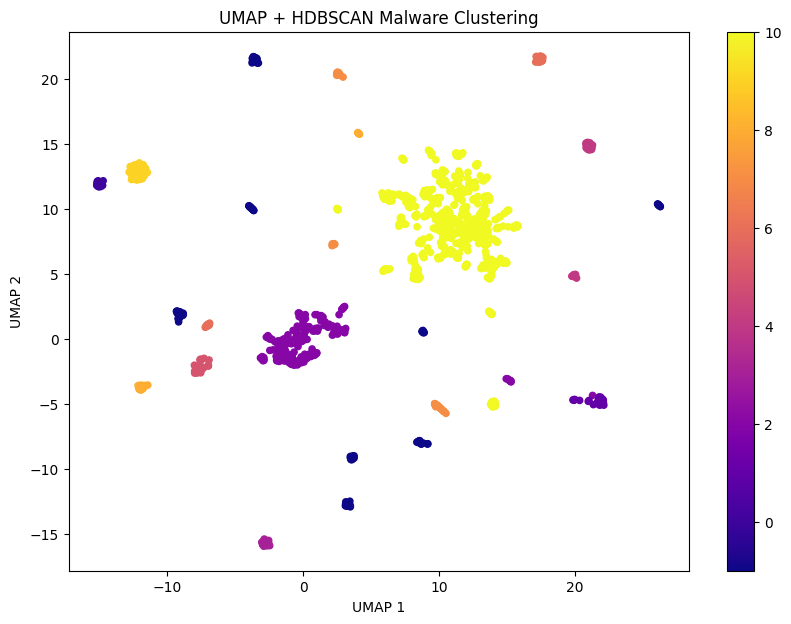

In [17]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=hdbscan_labels,
    cmap='plasma',
    s=20
)

plt.title("UMAP + HDBSCAN Malware Clustering")

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.colorbar(scatter)

plt.show()

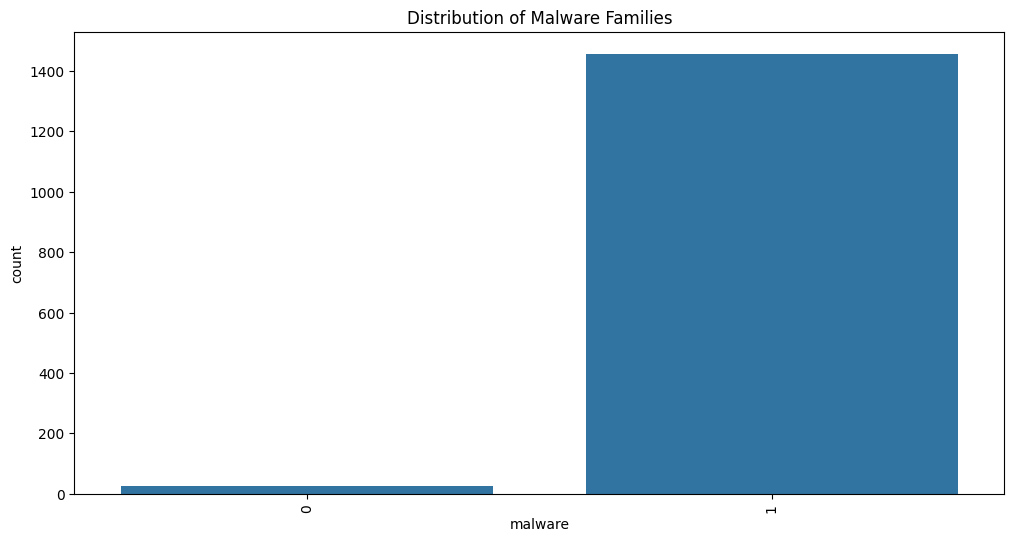

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=y_clean
)

plt.title("Distribution of Malware Families")

plt.xticks(rotation=90)

plt.show()

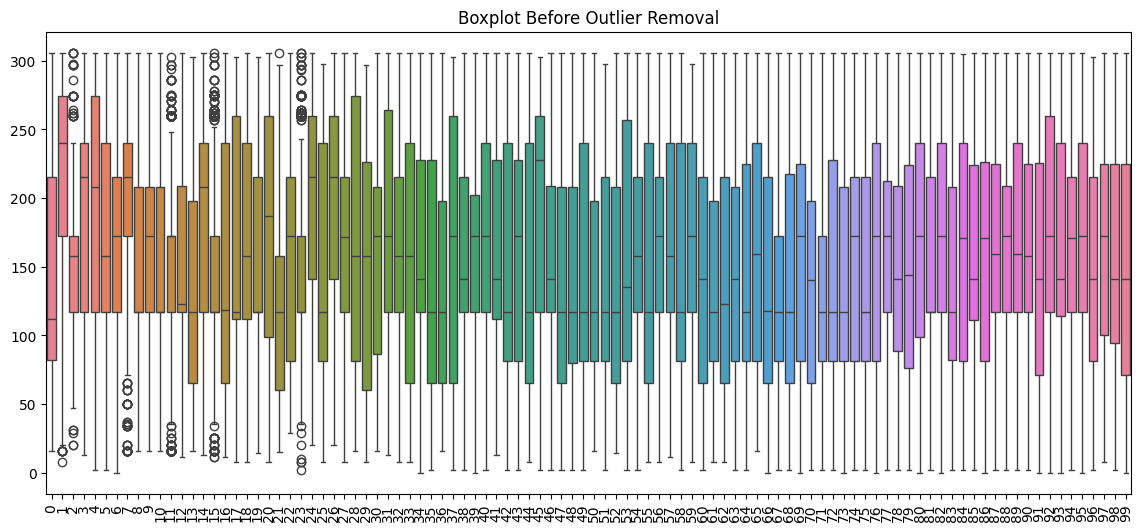

In [19]:
plt.figure(figsize=(14,6))

sns.boxplot(data=pd.DataFrame(X_imputed))

plt.title("Boxplot Before Outlier Removal")

plt.xticks(rotation=90)

plt.show()

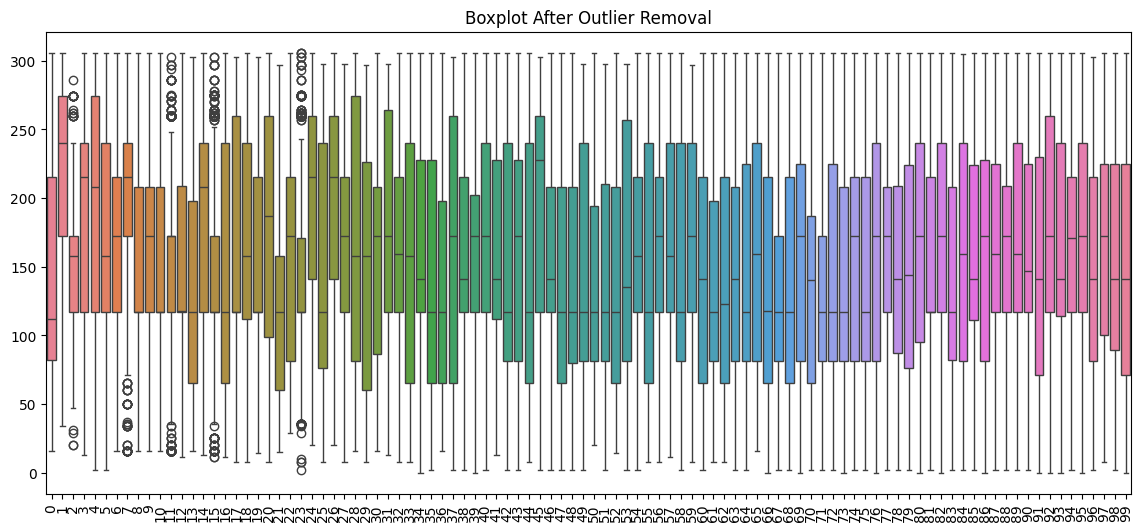

In [20]:
plt.figure(figsize=(14,6))

sns.boxplot(data=pd.DataFrame(X_clean))

plt.title("Boxplot After Outlier Removal")

plt.xticks(rotation=90)

plt.show()

In [28]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("\n=========== AGGLOMERATIVE RESULTS ===========\n")

best_sil = -1
best_k = None
best_labels = None
best_dbi = None
best_ch = None   # ✅ add this

for k in range(2, 8):

    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = agglo.fit_predict(X_umap)

    sil = silhouette_score(X_umap, labels)
    dbi = davies_bouldin_score(X_umap, labels)
    ch = calinski_harabasz_score(X_umap, labels)   # ✅ ADD CH

    print(f"K = {k}")
    print(f"Silhouette = {sil:.4f}")
    print(f"DBI        = {dbi:.4f}")
    print(f"CH Score   = {ch:.4f}")   # ✅ print CH
    print("-"*40)

    if sil > best_sil:
        best_sil = sil
        best_k = k
        best_labels = labels
        best_dbi = dbi
        best_ch = ch   # ✅ store CH for best model


=========== AGGLOMERATIVE RESULTS ===========

K = 2
Silhouette = 0.3960
DBI        = 1.3781
CH Score   = 628.1732
----------------------------------------
K = 3
Silhouette = 0.4552
DBI        = 1.0154
CH Score   = 626.0987
----------------------------------------
K = 4
Silhouette = 0.4817
DBI        = 0.9226
CH Score   = 668.4058
----------------------------------------
K = 5
Silhouette = 0.5342
DBI        = 0.8990
CH Score   = 737.8000
----------------------------------------
K = 6
Silhouette = 0.5871
DBI        = 0.9291
CH Score   = 820.3339
----------------------------------------
K = 7
Silhouette = 0.6074
DBI        = 0.8161
CH Score   = 822.4951
----------------------------------------


In [30]:
print("\n=========== BEST AGGLOMERATIVE RESULTS ===========\n")

print("Best K          :", best_k)
print("Best Silhouette :", round(best_sil,4))
print("Best DBI        :", round(best_dbi,4))
print("Best CH Score   :", round(best_ch,4))


=========== BEST AGGLOMERATIVE RESULTS ===========

Best K          : 7
Best Silhouette : 0.6074
Best DBI        : 0.8161
Best CH Score   : 822.4951


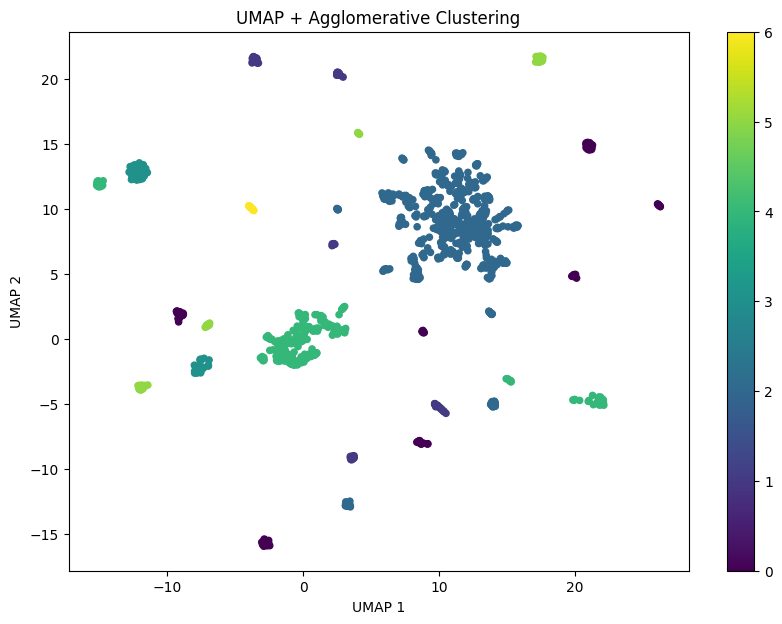

In [23]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=best_labels,
    cmap='viridis',
    s=20
)

plt.title("UMAP + Agglomerative Clustering")

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.colorbar(scatter)

plt.show()

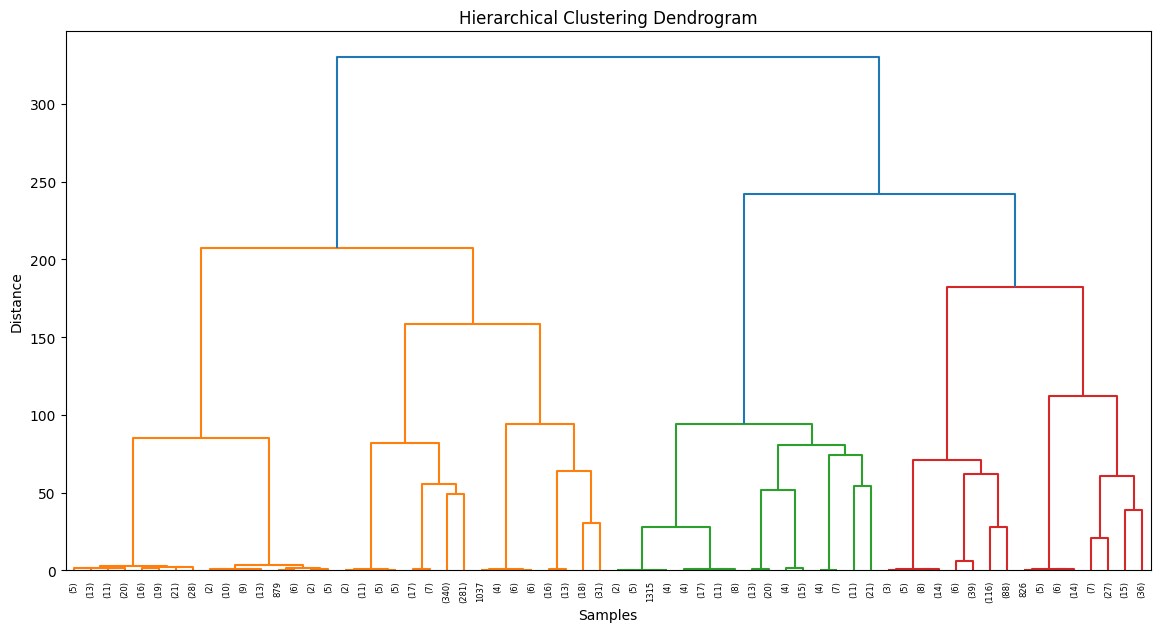

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(
    X_umap,
    method='ward'
)

plt.figure(figsize=(14,7))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Samples")

plt.ylabel("Distance")

plt.show()